In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import warnings
warnings.filterwarnings("ignore")

In [ ]:
excel_file = pd.ExcelFile("Retail-Supply-Chain-Sales-Dataset.xlsx")
print(excel_file.sheet_names)

['Retails Order Full Dataset', 'Calendar Table']


In [ ]:
df = pd.read_excel("Retail-Supply-Chain-Sales-Dataset.xlsx", sheet_name="Retails Order Full Dataset")
calender = pd.read_excel("Retail-Supply-Chain-Sales-Dataset.xlsx", sheet_name="Calendar Table")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Retail Sales People,Product ID,Category,Sub-Category,Product Name,Returned,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,Not,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Not,731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06,2016-12-06,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Anna Andreadi,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,Not,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10,2015-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Cassandra Brandow,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,Not,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10,2015-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Cassandra Brandow,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,Not,22.3680,2,0.20,2.5164


In [ ]:
calender.head()

,Date,Year,Quarter,Quarter (Q),Quarter & Year,Month,Month Name,Month & Year,Week of Year,Week of Year (W),Day of Week,Day Name
0,2016-07-01,2016,3,Q3,2016 - Q3,7,Jul,Jul 2016,27,Week 27,5,Friday
1,2016-07-02,2016,3,Q3,2016 - Q3,7,Jul,Jul 2016,27,Week 27,6,Saturday
2,2016-07-03,2016,3,Q3,2016 - Q3,7,Jul,Jul 2016,27,Week 27,7,Sunday
3,2016-07-04,2016,3,Q3,2016 - Q3,7,Jul,Jul 2016,28,Week 28,1,Monday
4,2016-07-05,2016,3,Q3,2016 - Q3,7,Jul,Jul 2016,28,Week 28,2,Tuesday


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
calender['Date'] = pd.to_datetime(calender['Date'])

order_date_df = calender[['Date', 'Year', 'Quarter', 'Month Name', 'Week of Year', 'Day Name']].rename(columns={
    'Year': "Order Year",
    'Quarter': 'Order Quarter',
    "Month Name": "Order Month",
    "Week of Year": "Order Week",
    "Day Name": "Order Day"
    })

ship_date_df = calender[['Date', 'Year', 'Quarter', 'Month Name', 'Week of Year', 'Day Name']].rename(columns={
    'Year': "Ship Year",
    'Quarter': 'Ship Quarter',
    "Month Name": "Ship Month",
    "Week of Year": "Ship Week",
    "Day Name": "Ship Day"
    })

final_df = pd.merge(df, order_date_df, left_on='Order Date', right_on='Date', how='left')
final_df = final_df.drop(columns=['Date'])
final_df = pd.merge(final_df, ship_date_df, left_on='Ship Date', right_on='Date', how='left')
final_df = final_df.drop(columns=['Date'])

final_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Order Year,Order Quarter,Order Month,Order Week,Order Day,Ship Year,Ship Quarter,Ship Month,Ship Week,Ship Day
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2016,3,Aug,33,Thursday,2016,4,Nov,46,Friday
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2016,3,Aug,33,Thursday,2016,4,Nov,46,Friday
2,3,CA-2016-138688,2016-12-06,2016-12-06,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2016,4,Dec,50,Tuesday,2016,4,Dec,50,Tuesday
3,4,US-2015-108966,2015-11-10,2015-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2015,4,Nov,46,Tuesday,2015,4,Nov,46,Tuesday
4,5,US-2015-108966,2015-11-10,2015-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2015,4,Nov,46,Tuesday,2015,4,Nov,46,Tuesday


In [ ]:
final_df.shape

(9994, 33)

In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Row ID               9994 non-null   int64         
 1   Order ID             9994 non-null   object        
 2   Order Date           9994 non-null   datetime64[ns]
 3   Ship Date            9994 non-null   datetime64[ns]
 4   Ship Mode            9994 non-null   object        
 5   Customer ID          9994 non-null   object        
 6   Customer Name        9994 non-null   object        
 7   Segment              9994 non-null   object        
 8   Country              9994 non-null   object        
 9   City                 9994 non-null   object        
 10  State                9994 non-null   object        
 11  Postal Code          9994 non-null   int64         
 12  Region               9994 non-null   object        
 13  Retail Sales People  9994 non-nul

In [ ]:
final_df = final_df.drop(columns=['Row ID', 'Order ID', 'Customer ID', 'Customer Name', 'Product ID', 'Product Name'])

In [ ]:
# Missing Values
missing = final_df.isnull().sum()
missing_pct = (missing / len(final_df)) * 100
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False)
print(missing_df)

Empty DataFrame
Columns: [count, pct]
Index: []


In [ ]:
# Duplilcates
duplicated = final_df.duplicated().sum()
duplicated_pct = (duplicated / len(final_df)) * 100
print(f"count: {duplicated}, pct: {duplicated_pct}")

count: 1, pct: 0.010006003602161296


In [ ]:
final_df = final_df.drop_duplicates()
final_df.shape

(9993, 27)

In [ ]:
categ_cols = final_df.select_dtypes(include=['O']).columns.to_list()
final_df[categ_cols].nunique()

,0
Ship Mode,4
Segment,3
Country,1
City,531
State,49
Region,4
Retail Sales People,4
Category,3
Sub-Category,17
Returned,2


In [ ]:
print("Ship Mode : ", final_df['Ship Mode'].unique())
print("Segment   : ", final_df['Segment'].unique())
print("Region    : ", final_df['Region'].unique())
print("Category  : ", final_df['Category'].unique())
print("Retail Sales People    : ", final_df['Retail Sales People'].unique())

Ship Mode :  ['Second Class' 'Standard Class' 'First Class' 'Same Day']
Segment   :  ['Consumer' 'Corporate' 'Home Office']
Region    :  ['South' 'West' 'Central' 'East']
Category  :  ['Furniture' 'Office Supplies' 'Technology']
Retail Sales People    :  ['Cassandra Brandow' 'Anna Andreadi' 'Kelly Williams' 'Chuck Magee']


In [ ]:
final_df = final_df.drop(columns=['Country', 'Retail Sales People'])

In [ ]:
profit = final_df['Profit']

print(f"Mean    : ${profit.mean():.2f}")
print(f"Median  : ${profit.median():.2f}")
print(f"Std     : ${profit.std():.2f}")
print(f"Skew    : {profit.skew():.3f}")
print(f"Kurt    : {profit.kurtosis():.3f}")
print(f"p1      : ${profit.quantile(0.01):.2f}")
print(f"p99     : ${profit.quantile(0.99):.2f}")

outlier_pct = ((profit < profit.quantile(0.01)) | (profit > profit.quantile(0.99))).mean() * 100
print(f"Outliers: {outlier_pct:.1f}%  (outside p1–p99)")

Mean    : $28.66
Median  : $8.67
Std     : $234.27
Skew    : 7.561
Kurt    : 397.150
p1      : $-319.28
p99     : $580.67
Outliers: 2.0%  (outside p1–p99)


Simple EDA

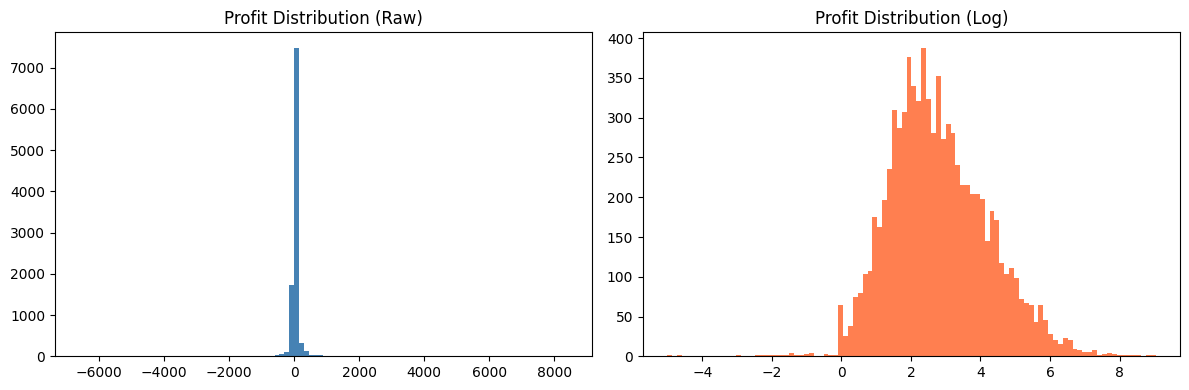

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(final_df['Profit'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Profit Distribution (Raw)')
axes[1].hist(np.log1p(final_df['Profit']), bins=100, color='coral', edgecolor='none')
axes[1].set_title('Profit Distribution (Log)')
plt.tight_layout()
plt.show()

          median       mean         std  count
Region                                        
West     11.1664  33.849032  174.109081   3203
South     9.0720  28.857673  212.893088   1620
East      8.1717  32.135808  251.605084   2848
Central   5.1840  17.092709  291.487465   2323


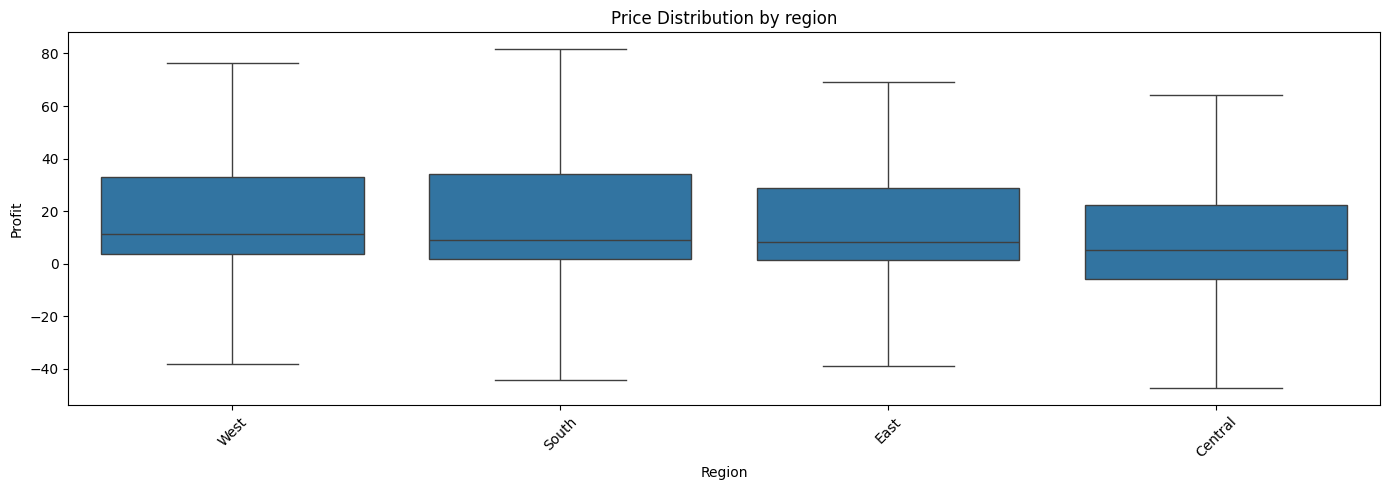

In [ ]:
# Price by city
region_stats = df.groupby('Region')['Profit'].agg(['median', 'mean', 'std', 'count'])
region_stats = region_stats.sort_values('median', ascending=False)
print(region_stats)

# Visualization
plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x='Region', y='Profit',
            order=region_stats.index,
            showfliers=False)
plt.xticks(rotation=45)
plt.title('Price Distribution by region')
plt.tight_layout()
plt.show()

                         median        mean         std  count
State                                                         
Wyoming               100.19600  100.196000         NaN      1
Vermont                67.65990  204.088936  301.653921     11
Maine                  30.73400   56.810775   53.816911      8
Wisconsin              25.10085   76.380004  124.946125    110
Michigan               24.22560   95.934069  374.559894    255
Nevada                 23.80800   85.045279  265.901543     39
Maryland               23.68080   66.963608  148.214655    105
Oklahoma               23.53605   73.544788  109.026519     66
Mississippi            23.40000   59.867475   80.793505     53
Georgia                22.24690   88.315453  283.026694    184
Kentucky               21.77280   80.573357  171.126404    139
West Virginia          21.71680   46.480400  125.265494      4
Delaware               19.19700  103.930988  518.953513     96
Virginia               19.18125   83.026564  235.266720

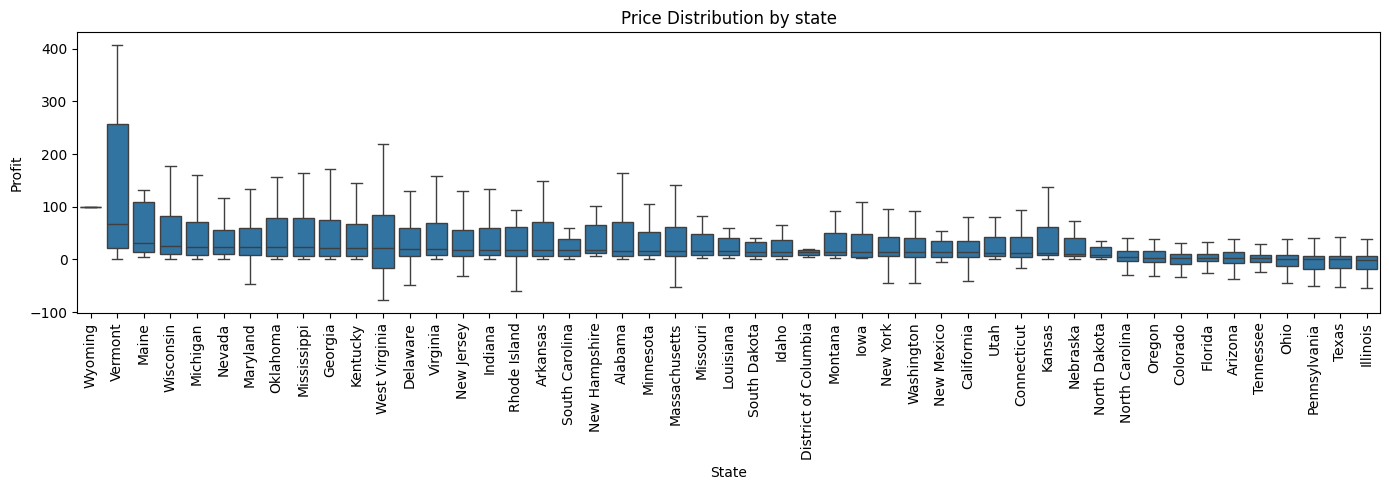

In [ ]:
# Price by city
state_stats = df.groupby('State')['Profit'].agg(['median', 'mean', 'std', 'count'])
state_stats = state_stats.sort_values('median', ascending=False)
print(state_stats)

# Visualization
plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x='State', y='Profit',
            order=state_stats.index,
            showfliers=False)
plt.xticks(rotation=90)
plt.title('Price Distribution by state')
plt.tight_layout()
plt.show()

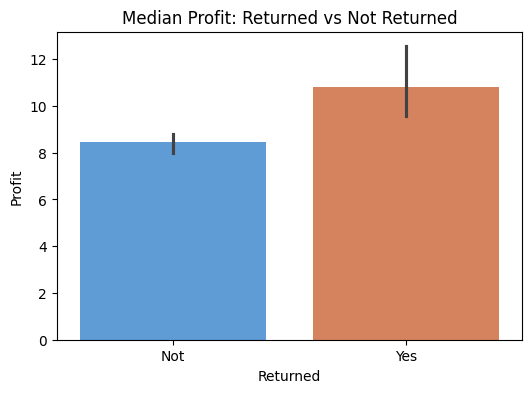

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Returned',
    y='Profit',
    data=final_df,
    estimator='median',
    palette=['#4C9BE8', '#E87B4C']
)

plt.title('Median Profit: Returned vs Not Returned')
plt.show()

In [ ]:
num_cols = final_df.select_dtypes(include=['number']).columns.to_list()


corr = final_df[num_cols].corr()

# Top features correlated with profit
profit_corr = corr["Profit"].abs().sort_values(ascending=False).drop("Profit")
print("Top features by |correlation| with Profit:")
print(profit_corr.round(3).to_string())


Top features by |correlation| with Profit:
Sales            0.479
Discount         0.219
Quantity         0.066
Postal Code      0.030
Order Quarter    0.018
Ship Quarter     0.017
Order Week       0.014
Ship Week        0.010
Order Year       0.005
Ship Year        0.005


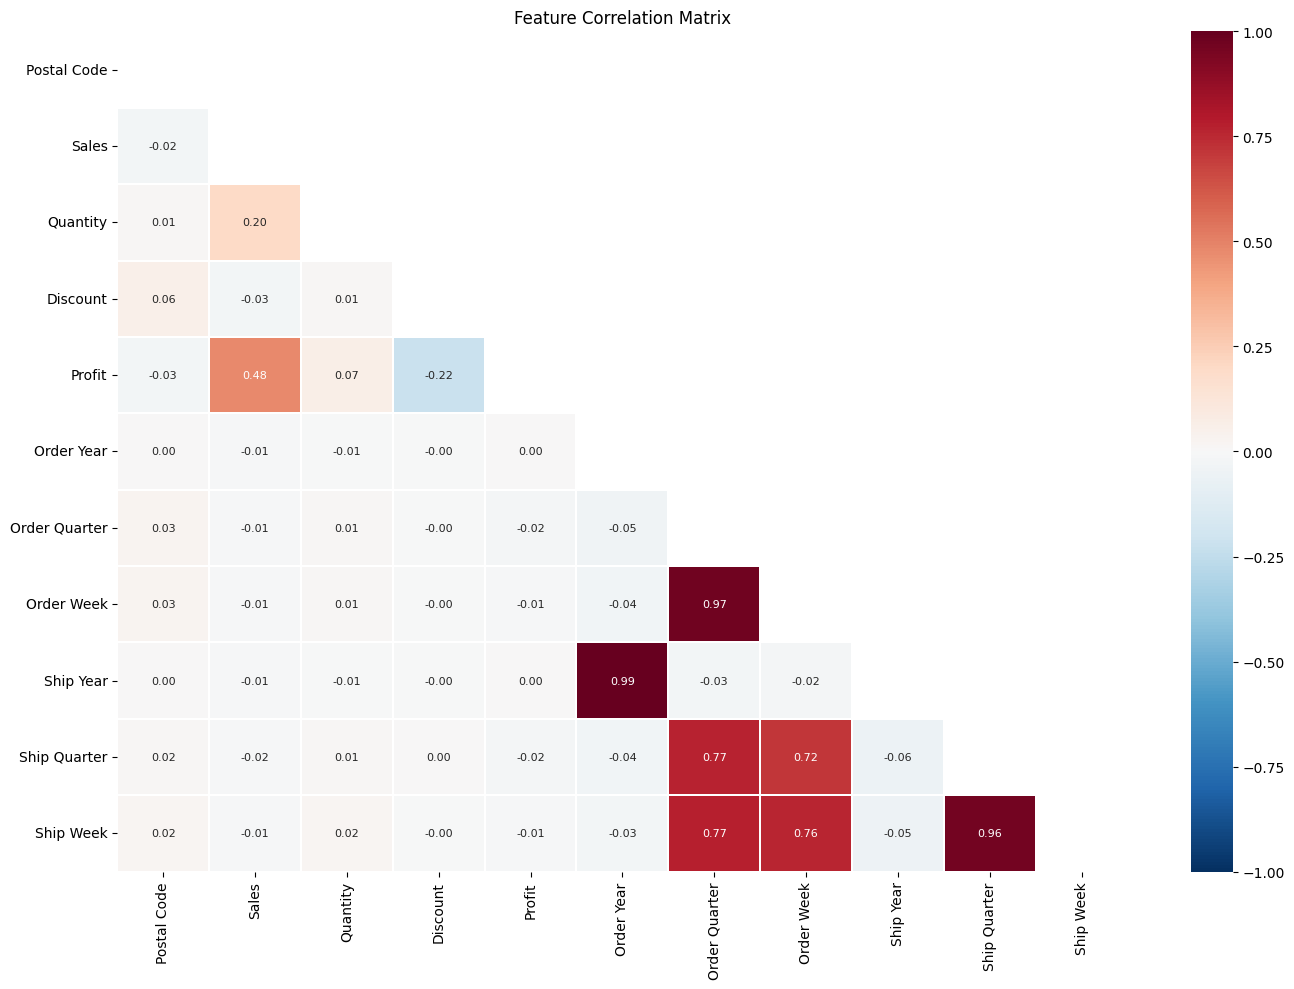

In [ ]:
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.3, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Outlier capping
lower_cap = final_df['Profit'].quantile(0.01)
upper_cap = final_df['Profit'].quantile(0.99)
clipped_profit = final_df['Profit'].clip(lower=lower_cap, upper=upper_cap)

# Apply sign-preserving log1p
final_df['Profit log'] = np.sign(clipped_profit) * np.log1p(np.abs(clipped_profit))
print(f'Shape: {final_df.shape}')
print(f'Skew raw: {final_df["Profit"].skew():.2f}  log: {final_df["Profit log"].skew():.2f}')

Shape: (9993, 26)
Skew raw: 7.56  log: -0.99


In [ ]:
X = final_df.drop(columns=['Profit', 'Profit log'])
y = final_df['Profit log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (7494, 24) | Test: (2499, 24)


## Transformers

In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order Date     9993 non-null   datetime64[ns]
 1   Ship Date      9993 non-null   datetime64[ns]
 2   Ship Mode      9993 non-null   object        
 3   Segment        9993 non-null   object        
 4   City           9993 non-null   object        
 5   State          9993 non-null   object        
 6   Postal Code    9993 non-null   int64         
 7   Region         9993 non-null   object        
 8   Category       9993 non-null   object        
 9   Sub-Category   9993 non-null   object        
 10  Returned       9993 non-null   object        
 11  Sales          9993 non-null   float64       
 12  Quantity       9993 non-null   int64         
 13  Discount       9993 non-null   float64       
 14  Profit         9993 non-null   float64       
 15  Order Year     9993 non-nu

In [ ]:
# Profit Predection

In [ ]:
# Encode Features
class EncodeFeatures(BaseEstimator, TransformerMixin):
    Ship_modes = {"Standard Class": 0, "Second Class": 1, "First Class": 2, "Same Day": 3}
    Segments   = {"Consumer": 0, "Corporate": 1, "Home Office": 2}
    Months     = {"Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4, "May": 5, "Jun": 6,
                  "Jul": 7, "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12}
    Days       = {"Saturday": 0, "Sunday": 1, "Monday": 2, "Tuesday": 3,
                  "Wednesday": 4, "Thursday": 5, "Friday": 6}

    def __init__(self):
        self.encoder_ = OneHotEncoder(sparse_output=False, dtype="int", handle_unknown='ignore')

    def fit(self, X, y):
        tmp = X.copy()
        tmp["__y__"] = y.values
        self.city_map_   = tmp.groupby("City")["__y__"].mean()
        self.state_map_  = tmp.groupby("State")["__y__"].mean()
        self.postal_map_ = tmp.groupby("Postal Code")["__y__"].mean()
        self.category_map_ = tmp.groupby("Category")["__y__"].mean()
        self.sub_cat_map_ = tmp.groupby("Sub-Category")["__y__"].mean()

        self.encoder_.fit(X[["Region"]])
        return self

    def transform(self, X):
        X = X.copy()
        X["Returned"]  = X["Returned"].map({"Not": 0, "Yes": 1})
        X["Ship Mode"] = X["Ship Mode"].map(self.Ship_modes)
        X["Segment"] = X["Segment"].map(self.Segments)
        X["City"]  = X["City"].map(self.city_map_).fillna(self.city_map_.mean())
        X["State"]  = X["State"].map(self.state_map_).fillna(self.state_map_.mean())
        X["Category"]  = X["Category"].map(self.category_map_).fillna(self.category_map_.mean())
        X["Sub-Category"]  = X["Sub-Category"].map(self.sub_cat_map_).fillna(self.sub_cat_map_.mean())
        X["Postal Code"]  = X["Postal Code"].map(self.postal_map_).fillna(self.postal_map_.mean())
        X["Order Month"] = X["Order Month"].map(self.Months)
        X["Ship Month"] = X["Ship Month"].map(self.Months)
        X["Order Day"] = X["Order Day"].map(self.Days)
        X["Ship Day"] = X["Ship Day"].map(self.Days)

        encoded_array = self.encoder_.transform(X[["Region"]])
        encoded_cols = self.encoder_.get_feature_names_out(["Region"])
        encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=X.index)
        X = pd.concat([X, encoded_df], axis=1).drop(columns=["Region"])

        return X

In [ ]:
# Outlier Clipper
class OutlierClipper(BaseEstimator, TransformerMixin):
    BINARY = ["Returned", "On Time Delivery"]

    def fit(self, X, y=None):
        self.bounds_ = {}
        for col in X.select_dtypes(include=[np.number]).columns:
            if col not in self.BINARY:
                Q1, Q3 = X[col].quantile(0.25), X[col].quantile(0.75)
                IQR = Q3 - Q1
                self.bounds_[col] = (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
        return self

    def transform(self, X):
        X = X.copy()
        for col, (lo, hi) in self.bounds_.items():
            if col in X.columns:
                X[col] = X[col].clip(lo, hi)
        return X

In [ ]:
# Feature Engineer
class FeatureEngineer(BaseEstimator, TransformerMixin):

    shipping_thresholds = {
    "Same Day": 0,
    "First Class": 1,
    "Second Class": 3,
    "Standard Class": 5
    }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Shipping Duration
        X["Shipping Duration"] = (X['Ship Date'] - X['Order Date']).dt.days

        # Count City Orders
        X['Count City Orders'] = X['City'].map(X['City'].value_counts())

        # Unit Base Price for product
        X['Unit Base Price'] = (X['Sales'] / X['Quantity']) * (1 - X['Discount'])

        # Actual Mony Discounted
        X['Discount Amount'] = X['Unit Base Price'] * X['Quantity'] * X['Discount']

        # On Time Delivery
        X['Max_Allowed_Days'] = X['Ship Mode'].map(self.shipping_thresholds)
        X['On Time Delivery'] = (X['Shipping Duration'] <= X['Max_Allowed_Days']).astype(int)
        X = X.drop(columns=['Max_Allowed_Days'])

        return X

In [ ]:
# Scale Features
class ScaleFeatures(BaseEstimator, TransformerMixin):
    BINARY = ["Returned", "On Time Delivery"]

    def fit(self, X, y=None):
        self.scale_cols_ = [c for c in X.select_dtypes(include=[np.number]).columns
                            if c not in self.BINARY]
        self.scaler_ = StandardScaler()
        self.scaler_.fit(X[self.scale_cols_])
        return self

    def transform(self, X):
        X = X.copy()
        X[self.scale_cols_] = self.scaler_.transform(X[self.scale_cols_])
        return X

In [ ]:
class DropingColumns(BaseEstimator, TransformerMixin):
    COLUMNS = ["Order Date", "Ship Date"]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.drop(columns=self.COLUMNS)
        return X

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import VarianceThreshold

class FeatureSelection(BaseEstimator, TransformerMixin):
    def __init__(self, min_votes=2):
        self.min_votes = min_votes
        self.selected_features_ = None

    def fit(self, X, y):
        # 1. Variance Threshold
        vt = VarianceThreshold(threshold=0.001)
        vt.fit(X)
        vt_keep = set(X.columns[vt.get_support()])

        # 2. Correlation
        corr_target = X.corrwith(y).abs().sort_values(ascending=False)
        corr_top = set(corr_target.head(int(len(corr_target) * 0.65)).index)

        # 3. Random Forest
        rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
        rf.fit(X, y)
        rf_imp = pd.Series(rf.feature_importances_, index=X.columns)
        rf_top = set(rf_imp[rf_imp >= 0.005].index)

        # 4. Lasso
        lasso = LassoCV(cv=5, random_state=42, max_iter=2000, n_jobs=-1)
        lasso.fit(X, y)
        lasso_coef = pd.Series(np.abs(lasso.coef_), index=X.columns)
        lasso_keep = set(lasso_coef[lasso_coef > 0].index)

        # 5. Vote counting
        keep_features = []
        for col in X.columns:
            votes = sum([col in vt_keep, col in corr_top, col in rf_top, col in lasso_keep])
            if votes >= self.min_votes:
                keep_features.append(col)

        self.selected_features_ = keep_features
        return self

    def transform(self, X):
        # Returns ONLY the columns that won the vote
        if isinstance(X, pd.DataFrame):
            return X[self.selected_features_]
        else:
            # Handle cases where previous pipeline steps outputted a numpy array
            return X[:, [self.selected_features_]]

In [ ]:
pipeline = Pipeline(steps=[
    ("encode",           EncodeFeatures()),
    ("clip_outliers",    OutlierClipper()),
    ("feature_engineer", FeatureEngineer()),
    ("scale",            ScaleFeatures()),
    ("drop",             DropingColumns()),
    ("select_features",  FeatureSelection())
])

print("Pipeline steps:")
for name, step in pipeline.steps:
    print(f"  {name:20s} -> {step.__class__.__name__}")

Pipeline steps:
  encode               -> EncodeFeatures
  clip_outliers        -> OutlierClipper
  feature_engineer     -> FeatureEngineer
  scale                -> ScaleFeatures
  drop                 -> DropingColumns
  select_features      -> FeatureSelection


In [ ]:
X_train_processed = pipeline.fit_transform(X_train, y_train)
X_test_processed  = pipeline.transform(X_test)

print(f"X_train: {X_train_processed.shape}")
print(f"X_test : {X_test_processed.shape}")
print(f"\nFeatures ({X_train_processed.shape[1]}):")
for i, c in enumerate(X_train_processed.columns, 1):
    print(f"  {i:2d}. {c}")

X_train: (7494, 22)
X_test : (2499, 22)

Features (22):
   1. Ship Mode
   2. Segment
   3. City
   4. State
   5. Postal Code
   6. Sub-Category
   7. Returned
   8. Sales
   9. Quantity
  10. Discount
  11. Order Month
  12. Order Week
  13. Order Day
  14. Ship Month
  15. Ship Week
  16. Ship Day
  17. Region_East
  18. Region_West
  19. Shipping Duration
  20. Count City Orders
  21. Unit Base Price
  22. Discount Amount


In [ ]:
scale_cols = pipeline.named_steps["scale"].scale_cols_

print("Scaled cols (mean=0, std=1):")
print(X_train_processed[scale_cols[:4]].agg(["mean","std"]).round(3))

print(f"\nNaN train: {X_train_processed.isnull().sum().sum()}")
print(f"NaN test : {X_test_processed.isnull().sum().sum()}")

Scaled cols (mean=0, std=1):
      Ship Mode  Segment  City  State
mean        0.0      0.0   0.0    0.0
std         1.0      1.0   1.0    1.0

NaN train: 0
NaN test : 0


## Saving Preprocessor

In [ ]:
import os

model_path = '/content/models/'
os.makedirs(model_path, exist_ok=True)

data_path = '/content/data/'
os.makedirs(data_path, exist_ok=True)

In [ ]:
import joblib

# Pipeline
joblib.dump(pipeline, model_path + "profit_prediction_pipeline.pkl")

['/content/models/profit_prediction_pipeline.pkl']

In [ ]:
# Data
train_out = X_train_final.copy()
train_out["Profit log"] = y_train.values
test_out  = X_test_final.copy()
test_out["Profit log"]  = y_test.values

train_out.to_csv(data_path + "train_final.csv", index=False)
test_out.to_csv(data_path + "test_final.csv", index=False)

# Start Modeling

In [ ]:
# Main libraries
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

# Metrics libraries
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Preprocessing
from sklearn.model_selection import train_test_split

# Machine learning libraries
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# pkl save model
import pickle

print('[DONE] Dependancies imports successfully.')

[DONE] Dependancies imports successfully.


In [ ]:
OUTPUT_DIR = "/content/outputs/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
train_df = pd.read_csv("/content/data/train_final.csv")
test_df  = pd.read_csv("/content/data/test_final.csv")

train_df.shape, test_df.shape

((7494, 19), (2499, 19))

In [ ]:
train_df.head()

,Discount,Sales,Sub-Category,Postal Code,Discount Amount,Unit Base Price,City,Shipping Duration,Quantity,Count City Orders,Order Week,Order Day,State,Ship Day,Ship Mode,Segment,Region_West,Region_East,Profit log
0,-0.873548,0.039056,-0.020220,0.493307,-0.504301,-0.142942,0.535922,1.618180,0.593480,0.850241,0.192435,-0.416686,0.575518,0.968796,-0.739512,-0.870659,1.455096,-0.629739,4.154765
1,-0.873548,-0.794368,-0.407387,1.191456,-0.504301,-0.691150,1.077036,-0.553674,-0.358170,-0.778945,-1.726405,1.035258,1.124183,-0.533720,-0.739512,-0.870659,-0.687240,-0.629739,0.000000
2,2.296605,0.109882,-1.072815,-1.673373,0.998602,0.859089,-0.862283,2.188752,-1.309821,-0.823337,-0.733902,-0.416686,-0.800013,-1.034559,-0.739512,0.442954,-0.687240,-0.629739,-4.759740
3,-0.873548,-0.534802,-1.072815,1.039861,-0.504301,-0.398302,1.128658,-0.590485,-0.358170,-0.770066,0.589436,-0.416686,0.743548,0.467957,1.581461,1.756568,-0.687240,1.587960,3.209811
4,-0.239517,2.136357,-0.639707,0.734313,1.203614,0.559699,0.723808,-0.553674,1.545130,2.119852,0.258602,-0.900668,0.692803,0.968796,-0.739512,-0.870659,-0.687240,1.587960,4.169545


In [ ]:
target_col = 'Profit log'

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

print(f'Train data shape: {train_df.shape[0]} Row, {train_df.shape[1]} Column')
print(f'Test data shape: {test_df.shape[0]} Row, {test_df.shape[1]} Column')

Train data shape: 7494 Row, 19 Column
Test data shape: 2499 Row, 19 Column


## Calc Metric Functions

In [ ]:
def calc_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return r2, mae, rmse

def r2_score_metric(y_true, y_pred):
    ss_res = K.sum(K.square(y_true - y_pred))
    ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - ss_res / (ss_tot + K.epsilon())

In [ ]:
results = []

## Base Models

In [ ]:
# BASE MODELS
## Mean Model
mean_trin_pred = np.full_like(y_train, y_train.mean())
mean_test_pred = np.full_like(y_test, y_train.mean())
r2_tr, mae_tr, rmse_tr = calc_metrics(y_train, mean_trin_pred)
r2_te, mae_te, rmse_te = calc_metrics(y_test, mean_test_pred)
results.append({
    'Model Name': 'Mean',
    'Model': np.nan,
    'Train R2': r2_tr,
    'Test R2': r2_te,
    'Train MAE': mae_tr,
    'Test MAE': mae_te,
    'Train RMSE': rmse_tr,
    'Test RMSE': rmse_te
    })

## Median Model
median_trin_pred = np.full_like(y_train, y_train.median())
median_test_pred = np.full_like(y_test, y_train.median())
r2_tr, mae_tr, rmse_tr = calc_metrics(y_train, median_trin_pred)
r2_te, mae_te, rmse_te = calc_metrics(y_test, median_test_pred)
results.append({
    'Model Name': 'Median',
    'Model': np.nan,
    'Train R2': r2_tr,
    'Test R2': r2_te,
    'Train MAE': mae_tr,
    'Test MAE': mae_te,
    'Train RMSE': rmse_tr,
    'Test RMSE': rmse_te
    })

## Linear Regresion
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_trin_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)
r2_tr, mae_tr, rmse_tr = calc_metrics(y_train, lr_trin_pred)
r2_te, mae_te, rmse_te = calc_metrics(y_test, lr_test_pred)
results.append({
    'Model Name': 'Linear Regresion',
    'Model' : lr_model,
    'Train R2': r2_tr,
    'Test R2': r2_te,
    'Train MAE': mae_tr,
    'Test MAE': mae_te,
    'Train RMSE': rmse_tr,
    'Test RMSE': rmse_te
    })

print("=== Base Models Summary ===")
print(pd.DataFrame(results).drop('Model', axis=1))

print('\n[DONE] Base models\' results saved')

=== Base Models Summary ===
         Model Name  Train R2   Test R2  Train MAE  Test MAE  Train RMSE  \
0              Mean  0.000000 -0.000069   2.006996  1.995944    2.673439   
1            Median -0.045128 -0.041454   1.933147  1.911225    2.733097   
2  Linear Regresion  0.617327  0.578416   1.227040  1.285111    1.653804   

   Test RMSE  
0   2.680404  
1   2.735302  
2   1.740313  

[DONE] Base models' results saved


## Machine Learning Models

In [ ]:
ml_trained_models = {}

trainin_models = {
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Elastic Net': ElasticNet(),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'XGBoost': XGBRegressor(),
    'LightGBM': LGBMRegressor(),
}

In [ ]:
print('Start Training ML Models...')
for model_name, model in trainin_models.items():
    try:
        print(f'    Training {model_name}...')
        model.fit(X_train, y_train)

        trin_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        r2_tr, mae_tr, rmse_tr = calc_metrics(y_train, trin_pred)
        r2_te, mae_te, rmse_te = calc_metrics(y_test, test_pred)

        results.append({
            'Model Name': model_name,
            'Model': model,
            'Train R2': r2_tr,
            'Test R2': r2_te,
            'Train MAE': mae_tr,
            'Test MAE': mae_te,
            'Train RMSE': rmse_tr,
            'Test RMSE': rmse_te
            })

        ml_trained_models[model_name] = model
        print(f'    [DONE]{model_name} trained!, R2: {r2_te:.4f}\n')
    except Exception as e:
        print(f'    [FAILED] to train {model_name}')
        print(f'    Exception: {type(e).__name__}')
        print(f'    Message: {e}\n')
print(f'[DONE] ML Models Trained. ({len(ml_trained_models)}/{len(trainin_models)})')

Start Training ML Models...
    Training Ridge...
    [DONE]Ridge trained!, R2: 0.5785

    Training Lasso...
    [DONE]Lasso trained!, R2: 0.3324

    Training Elastic Net...
    [DONE]Elastic Net trained!, R2: 0.3821

    Training SVR...
    [DONE]SVR trained!, R2: 0.7214

    Training KNN...
    [DONE]KNN trained!, R2: 0.6226

    Training Decision Tree...
    [DONE]Decision Tree trained!, R2: 0.6150

    Training Random Forest...
    [DONE]Random Forest trained!, R2: 0.7965

    Training Gradient Boosting...
    [DONE]Gradient Boosting trained!, R2: 0.7821

    Training XGBoost...
    [DONE]XGBoost trained!, R2: 0.7694

    Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001243 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1561
[Li

In [ ]:
all_results = pd.DataFrame(results).drop('Model', axis=1).sort_values(by='Test RMSE').reset_index(drop=True)
all_results.style.background_gradient(cmap='viridis', subset=all_results.keys()[1:])

,Model Name,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Random Forest,0.973682,0.796482,0.209884,0.583622,0.433706,1.209169
1,LightGBM,0.917607,0.793781,0.422923,0.608453,0.767388,1.217165
2,Gradient Boosting,0.821890,0.782051,0.627976,0.686712,1.128273,1.251304
3,XGBoost,0.977379,0.769423,0.240832,0.646436,0.402089,1.287044
4,SVR,0.759760,0.721384,0.686263,0.789610,1.310367,1.414779
5,KNN,0.767716,0.622605,0.848917,1.078175,1.288486,1.646582
6,Decision Tree,0.999985,0.615009,0.000170,0.699897,0.010415,1.663071
7,Ridge,0.617327,0.578461,1.227056,1.285057,1.653804,1.740220
8,Linear Regresion,0.617327,0.578416,1.227040,1.285111,1.653804,1.740313
9,Elastic Net,0.410544,0.382094,1.562930,1.596727,2.052561,2.106912


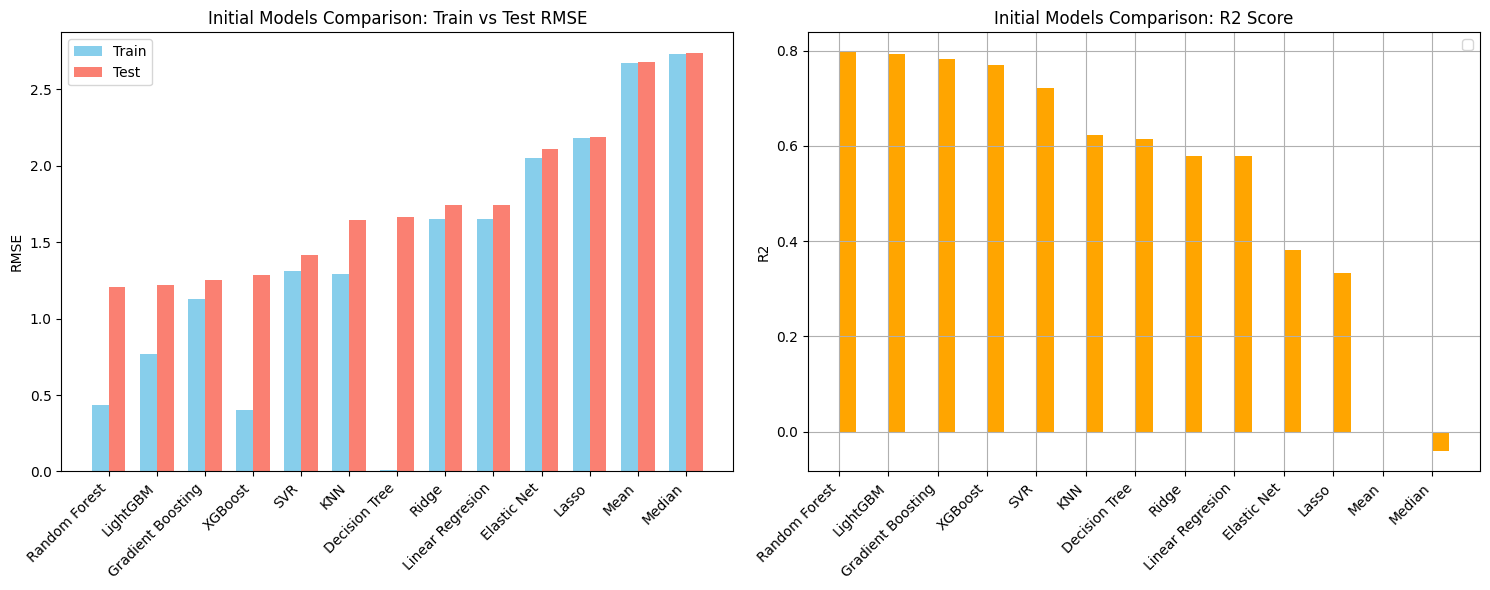

In [ ]:
plt.figure(figsize=(15, 6))
x = np.arange(len(all_results))
width = 0.35

# --- RMSE Plot ---
ax1 = plt.subplot(1,2,1)
ax1.bar(x - width/2, all_results['Train RMSE'], width, label='Train', color='skyblue')
ax1.bar(x + width/2, all_results['Test RMSE'], width, label='Test', color='salmon')

ax1.set_ylabel('RMSE')
ax1.set_title('Initial Models Comparison: Train vs Test RMSE')
ax1.set_xticks(x, all_results['Model Name'], rotation=45, ha='right')
ax1.legend()

# --- R2 Plot --
ax2 = plt.subplot(1,2,2)
ax2.bar(x + width/2, all_results['Test R2'], width, color='orange')

ax2.set_ylabel('R2')
ax2.set_title('Initial Models Comparison: R2 Score')
ax2.set_xticks(x, all_results['Model Name'], rotation=45, ha='right')
ax2.legend()

plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "initial_models_comparison.png"),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## Hyperparameter Tunning

In [ ]:
# Get the top 5 models based on Test RMSE from all_results
top_5_models_names = all_results['Model Name'].head(5).tolist()

print('TOP 5 Models Based on RMSE :-')
for model in top_5_models_names:
    print(f"\n  - {model}")
    print(f"    Train RMSE: {all_results[all_results['Model Name']==model]['Train RMSE'].iloc[0]:.4f}")
    print(f"    Test RMSE: {all_results[all_results['Model Name']==model]['Test RMSE'].iloc[0]:.4f}")

TOP 5 Models Based on RMSE :-

  - Random Forest
    Train RMSE: 0.4337
    Test RMSE: 1.2092

  - LightGBM
    Train RMSE: 0.7674
    Test RMSE: 1.2172

  - Gradient Boosting
    Train RMSE: 1.1283
    Test RMSE: 1.2513

  - XGBoost
    Train RMSE: 0.4021
    Test RMSE: 1.2870

  - SVR
    Train RMSE: 1.3104
    Test RMSE: 1.4148


In [ ]:
tuned_models = {}
best_params = {}

# Initialize models and their parameter grids
tuning_models = {
    'Random Forest': RandomForestRegressor(),
    'XGBoost': XGBRegressor(eval_metric='rmse'),
    'LightGBM': LGBMRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'SVR': SVR(),
}

param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None, 10, 20, 30, 50],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300, 500],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7, 10],
        'gamma': [0, 0.1, 0.3, 1],
        'subsample': [0.6, 0.8, 1.0],
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [31, 50, 100, 175],
        'max_depth': [3, 5, 10, 20],
        'min_child_samples': [10, 20, 30],
        'subsample': [0.6, 0.8, 1.0]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300, 500],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'subsample': [0.6, 0.8, 1.0],
        'max_features': ['sqrt', 'log2', None]
    },
    'SVR': {
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
        'C': [0.1, 1, 10, 100, 1000],
        'epsilon': [0.001, 0.01, 0.1, 0.5, 1],
        'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
    },
}

In [ ]:
print('Start Hyperparameter Tuning for Top 5 Models...')
for model_name in top_5_models_names:
    if model_name == 'SVR': continue
    if model_name in tuning_models and model_name in param_grids:
        print(f'    Tuning {model_name}...')
        model = tuning_models[model_name]
        param_grid = param_grids[model_name]

        grid_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid,
                                   scoring='neg_mean_squared_error', cv=3, n_jobs=-1, verbose=1)

        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        tuned_models[model_name] = best_model
        best_params[model_name] = grid_search.best_params_

        trin_pred = best_model.predict(X_train)
        test_pred = best_model.predict(X_test)

        r2_tr, mae_tr, rmse_tr = calc_metrics(y_train, trin_pred)
        r2_te, mae_te, rmse_te = calc_metrics(y_test, test_pred)

        results.append({
            'Model Name': f'{model_name} (Tuned)',
            'Model': best_model,
            'Train R2': r2_tr,
            'Test R2': r2_te,
            'Train MAE': mae_tr,
            'Test MAE': mae_te,
            'Train RMSE': rmse_tr,
            'Test RMSE': rmse_te
            })

        print(f'    [DONE] ({model_name} Tuned finished), Best Parameters: {grid_search.best_params_}, Test R2: {r2_te:.4f}\n')
    else:
        print(f'    [SKIP] tuning for {model_name}.\n')

print(f'Hyperparameter Tuning Done. ({len(tuned_models)} models tuned)')

Start Hyperparameter Tuning for Top 5 Models...
    Tuning Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
    [DONE] (Random Forest Tuned finished), Best Parameters: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 50}, Test R2: 0.8016

    Tuning LightGBM...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000439 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1561
[LightGBM] [Info] Number of data points in the train set: 7494, number of used features: 18
[LightGBM] [Info] Start training from score 1.700738
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

In [ ]:
tuning_res = []

for name,model in tuned_models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    r2_tr, mae_tr, rmse_tr = calc_metrics(y_train, y_train_pred)
    r2_te, mae_te, rmse_te = calc_metrics(y_test, y_test_pred)

    tuning_res.append({
        "Model Name" : name,
        'Train R2': r2_tr,
        'Test R2': r2_te,
        'Train MAE': mae_tr,
        'Test MAE': mae_te,
        'Train RMSE': rmse_tr,
        'Test RMSE': rmse_te

    })
    print(f"- ({name}) | TRAIN RMSE: {rmse_tr:.4f}, R2: {r2_tr:.4f} | Test RMSE: {rmse_te:.4f}, R2: {r2_te:.4f}")

- (Random Forest) | TRAIN RMSE: 0.7142, R2: 0.9286 | Test RMSE: 1.1939, R2: 0.8016
- (LightGBM) | TRAIN RMSE: 0.8987, R2: 0.8870 | Test RMSE: 1.2176, R2: 0.7936
- (Gradient Boosting) | TRAIN RMSE: 0.7209, R2: 0.9273 | Test RMSE: 1.2162, R2: 0.7941
- (XGBoost) | TRAIN RMSE: 0.7807, R2: 0.9147 | Test RMSE: 1.2208, R2: 0.7926


In [ ]:
res_df = pd.DataFrame(tuning_res).sort_values(by='Test RMSE').reset_index(drop=True)
res_df.style.background_gradient(cmap='viridis', subset=res_df.keys()[1:])

,Model Name,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Random Forest,0.928641,0.801599,0.340387,0.578856,0.714161,1.193871
1,Gradient Boosting,0.927279,0.794106,0.403586,0.610821,0.720939,1.216206
2,LightGBM,0.886993,0.793640,0.477436,0.620026,0.898716,1.217580
3,XGBoost,0.914724,0.792553,0.421333,0.607257,0.780700,1.220785


In [ ]:
all_results = pd.DataFrame(results).drop('Model', axis=1).sort_values(by='Test RMSE').reset_index(drop=True)
all_results.style.background_gradient(cmap='viridis', subset=all_results.keys()[1:])

,Model Name,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Random Forest (Tuned),0.928641,0.801599,0.340387,0.578856,0.714161,1.193871
1,Random Forest,0.973682,0.796482,0.209884,0.583622,0.433706,1.209169
2,Gradient Boosting (Tuned),0.927279,0.794106,0.403586,0.610821,0.720939,1.216206
3,LightGBM,0.917607,0.793781,0.422923,0.608453,0.767388,1.217165
4,LightGBM (Tuned),0.886993,0.793640,0.477436,0.620026,0.898716,1.217580
5,XGBoost (Tuned),0.914724,0.792553,0.421333,0.607257,0.780700,1.220785
6,Gradient Boosting,0.821890,0.782051,0.627976,0.686712,1.128273,1.251304
7,XGBoost,0.977379,0.769423,0.240832,0.646436,0.402089,1.287044
8,SVR,0.759760,0.721384,0.686263,0.789610,1.310367,1.414779
9,KNN,0.767716,0.622605,0.848917,1.078175,1.288486,1.646582


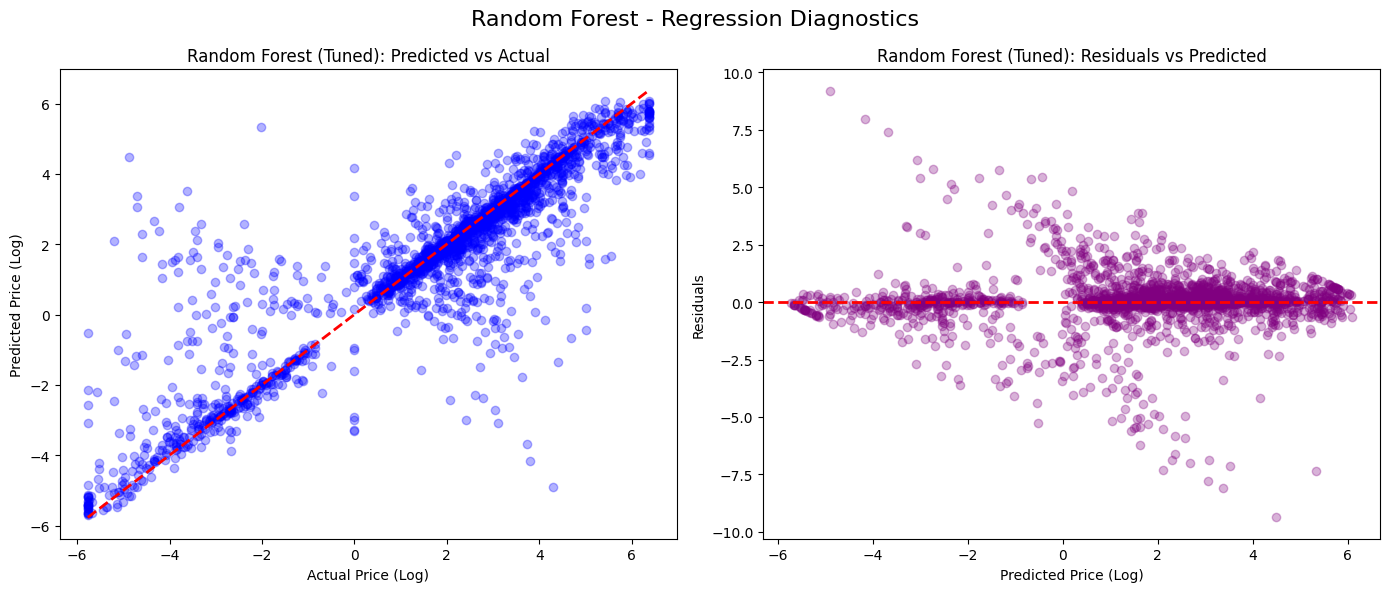

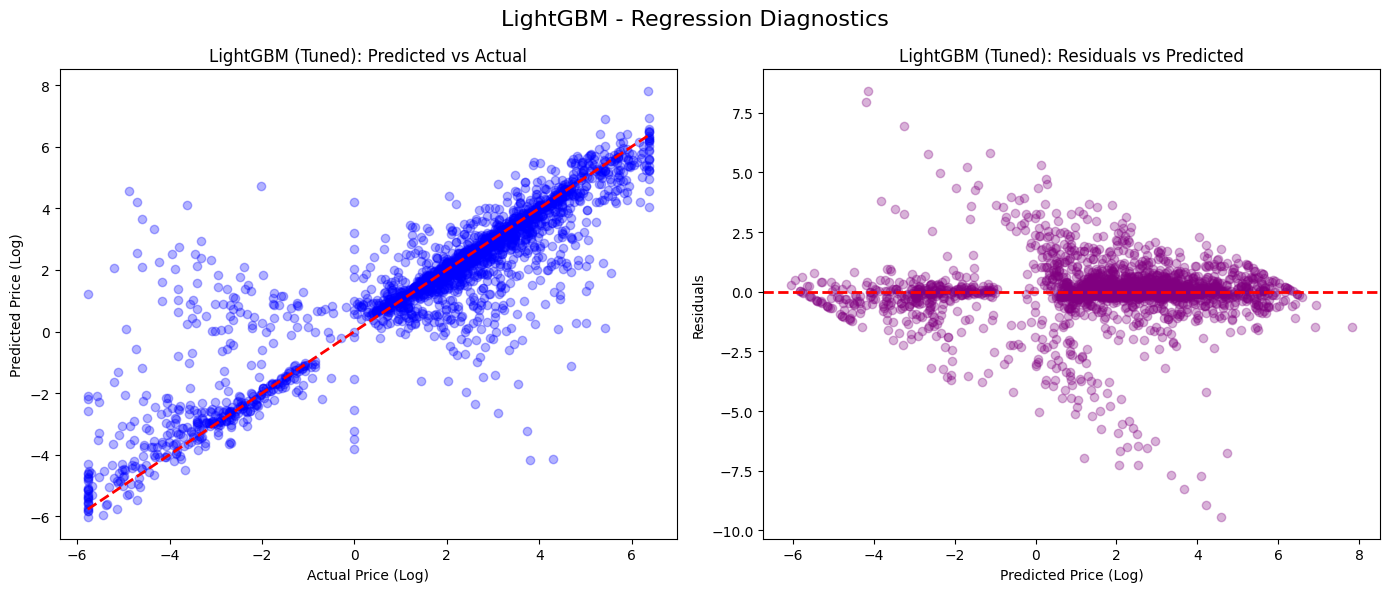

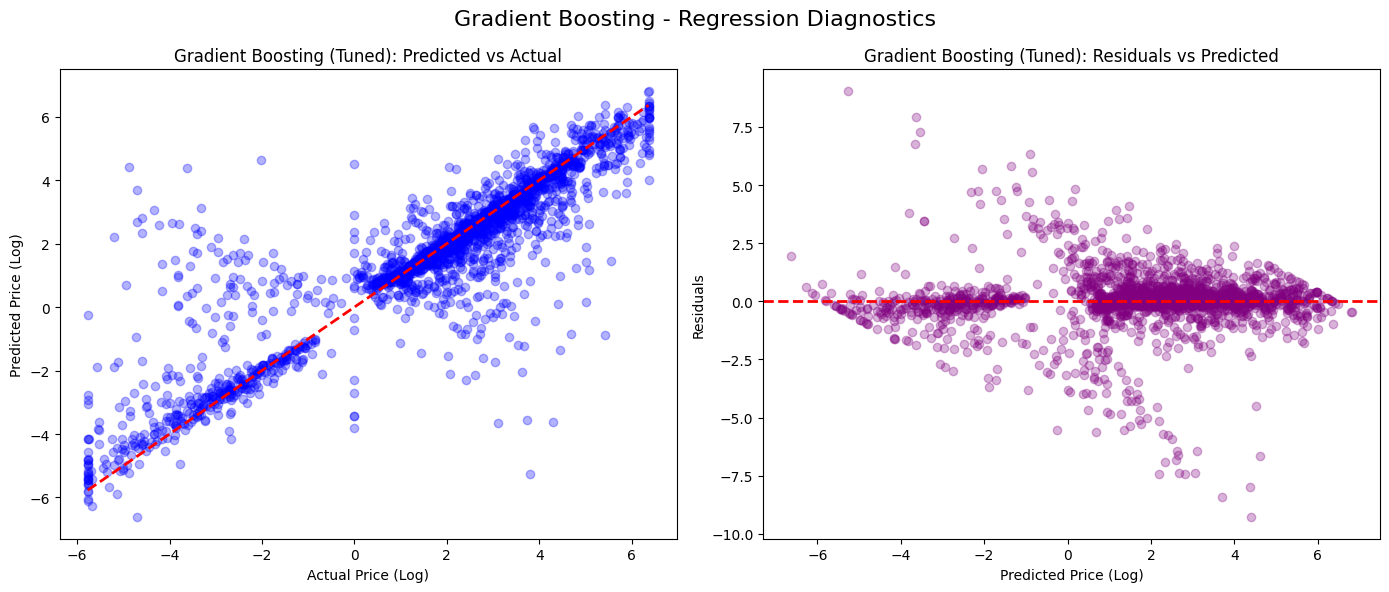

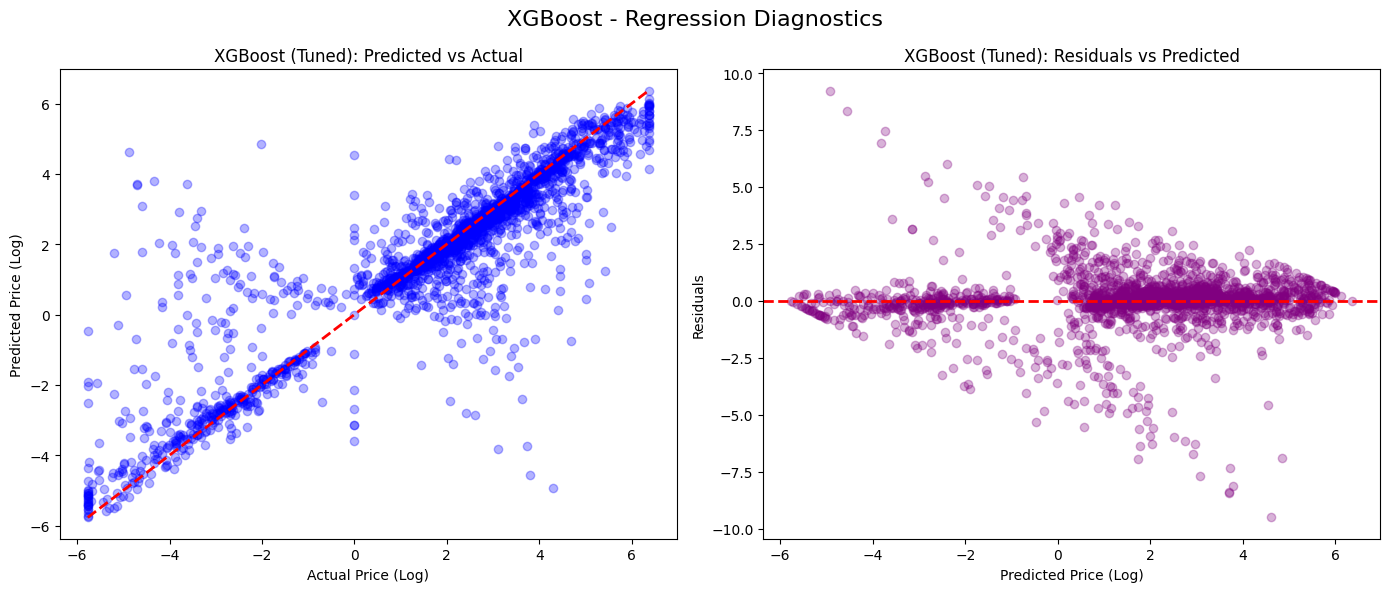

In [ ]:
# Predicted vs Actual
# plt.figure(figsize=(14, 20))

for i,model_info in enumerate(tuning_res):
    plt.figure(figsize=(14,6))
    model_name = model_info['Model Name']
    model = tuned_models[model_name]
    pred_test = model.predict(X_test)

    # --- Predicted VS Actual Plot --
    plt.subplot(1,2,1)
    plt.scatter(y_test, pred_test, alpha=0.3, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Price (Log)')
    plt.ylabel('Predicted Price (Log)')
    plt.title(f'{model_name} (Tuned): Predicted vs Actual')

    # --- Residuals VS Predicted ---
    plt.subplot(1,2,2)
    residuals = y_test - pred_test
    plt.scatter(pred_test, residuals, alpha=0.3, color='purple')
    plt.axhline(0, color='r', linestyle='--', lw=2)
    plt.xlabel('Predicted Price (Log)')
    plt.ylabel('Residuals')
    plt.title(f'{model_name} (Tuned): Residuals vs Predicted')

    plt.suptitle(f'{model_name} - Regression Diagnostics', fontsize=16)

    plt.savefig(
        os.path.join(OUTPUT_DIR, f"{model_name}_performance_analysis.png"),
        dpi=300,
        bbox_inches='tight'
    )
    plt.tight_layout()
    plt.show()
    print('')

In [ ]:
print('Start Hyperparameter Tuning for Top 5 Models...')
for model_name in top_5_models_names:
    if model_name == 'SVR': continue
    if model_name in tuning_models and model_name in param_grids:
        print(f'    Tuning {model_name}...')
        model = tuning_models[model_name]
        param_grid = param_grids[model_name]

        grid_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid,
                                   scoring='neg_mean_squared_error', cv=5, n_jobs=-1, verbose=1)

        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        tuned_models[model_name] = best_model
        best_params[model_name] = grid_search.best_params_

        trin_pred = best_model.predict(X_train)
        test_pred = best_model.predict(X_test)

        r2_tr, mae_tr, rmse_tr = calc_metrics(y_train, trin_pred)
        r2_te, mae_te, rmse_te = calc_metrics(y_test, test_pred)

        results.append({
            'Model Name': f'{model_name} (Tuned v2)',
            'Model': best_model,
            'Train R2': r2_tr,
            'Test R2': r2_te,
            'Train MAE': mae_tr,
            'Test MAE': mae_te,
            'Train RMSE': rmse_tr,
            'Test RMSE': rmse_te
            })

        print(f'    [DONE] ({model_name} Tuned finished), Best Parameters: {grid_search.best_params_}, Test R2: {r2_te:.4f}\n')
    else:
        print(f'    [SKIP] tuning for {model_name}.\n')

print(f'Hyperparameter Tuning Done. ({len(tuned_models)} models tuned)')

Start Hyperparameter Tuning for Top 5 Models...
    Tuning Random Forest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
    [DONE] (Random Forest Tuned finished), Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}, Test R2: 0.7961

    Tuning LightGBM...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000432 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1561
[LightGBM] [Info] Number of data points in the train set: 7494, number of used features: 18
[LightGBM] [Info] Start training from score 1.700738
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

KeyboardInterrupt: 

In [ ]:
all_results = pd.DataFrame(results).drop('Model', axis=1).sort_values(by='Test RMSE').reset_index(drop=True)
all_results.style.background_gradient(cmap='viridis', subset=all_results.keys()[1:])

,Model Name,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE
0,XGBoost (Tuned v2),0.918515,0.802200,0.407700,0.584971,0.763149,1.192062
1,Random Forest (Tuned),0.928641,0.801599,0.340387,0.578856,0.714161,1.193871
2,Random Forest,0.973682,0.796482,0.209884,0.583622,0.433706,1.209169
3,Random Forest (Tuned v2),0.973300,0.796145,0.212883,0.585699,0.436845,1.210170
4,Gradient Boosting (Tuned),0.927279,0.794106,0.403586,0.610821,0.720939,1.216206
5,LightGBM,0.917607,0.793781,0.422923,0.608453,0.767388,1.217165
6,LightGBM (Tuned),0.886993,0.793640,0.477436,0.620026,0.898716,1.217580
7,Gradient Boosting (Tuned v2),0.897779,0.793593,0.468231,0.620935,0.854750,1.217721
8,XGBoost (Tuned),0.914724,0.792553,0.421333,0.607257,0.780700,1.220785
9,LightGBM (Tuned v2),0.917705,0.786776,0.418553,0.627507,0.766932,1.237666


In [ ]:
last_results = pd.DataFrame(results).sort_values(by='Test RMSE').reset_index(drop=True)
top_model_raw = last_results.iloc[1]

top_model_name = top_model_raw["Model Name"]
top_model = top_model_raw["Model"]

print(f"Best Model : {top_model_name}")

Best Model : Random Forest (Tuned)


EVALUATION REPORT FOR: RandomForestRegressor

[INFO] Core Regression Metrics Summary:
     Metric  Train   Test
   R2 Score 0.9286 0.8016
Adjusted R2 0.9285 0.8002
        MAE 0.3404 0.5789
        MSE 0.5100 1.4253
       RMSE 0.7142 1.1939
------------------------------------------------------------


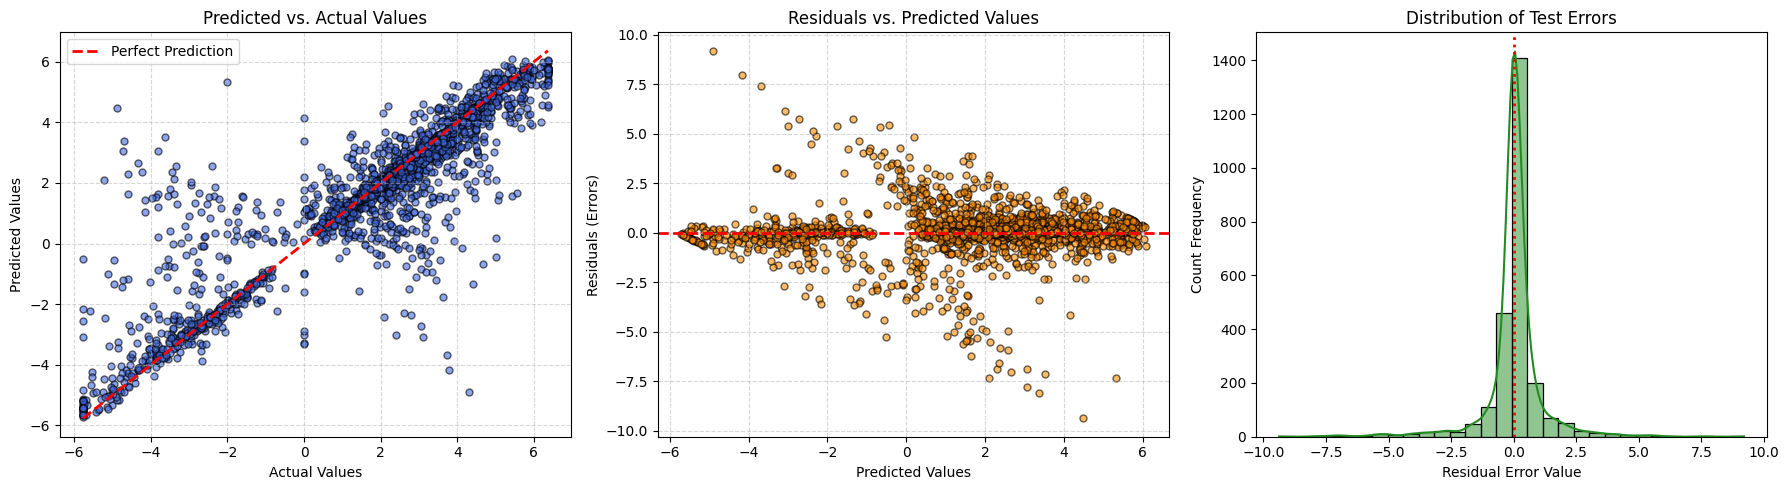

[SUCCESS] Regression diagnostic charts successfully saved to: /content/outputs/RandomForestRegressor_regression_evaluation.png



In [ ]:
print("="*60)
print(f"EVALUATION REPORT FOR: {type(top_model).__name__}")
print("="*60)

# 1. Generate Predictions
y_train_pred = top_model.predict(X_train)
y_test_pred = top_model.predict(X_test)

# 2. Helper Calculation for Adjusted R2
def get_adj_r2(r2, n, p):
    # n = number of samples, p = number of features
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

n_train, p = X_train.shape
n_test = X_test.shape[0]

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# 3. Calculate and Display Core Metrics Table
metrics = {
    'Metric': ['R2 Score', 'Adjusted R2', 'MAE', 'MSE', 'RMSE'],
    'Train': [
        r2_train,
        get_adj_r2(r2_train, n_train, p),
        mean_absolute_error(y_train, y_train_pred),
        mean_squared_error(y_train, y_train_pred),
        np.sqrt(mean_squared_error(y_train, y_train_pred))
    ],
    'Test': [
        r2_test,
        get_adj_r2(r2_test, n_test, p),
        mean_absolute_error(y_test, y_test_pred),
        mean_squared_error(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_test, y_test_pred))
    ]
}

metrics_df = pd.DataFrame(metrics)
print("\n[INFO] Core Regression Metrics Summary:")
print(metrics_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("-" * 60)

# Calculate residuals for plotting
residuals_test = y_test - y_test_pred

# 4. Plotting Diagnostic Regression Charts
plt.figure(figsize=(18, 5))

# --- Plot A: Predicted vs Actual (Perfect fit line is diagonal) ---
ax1 = plt.subplot(1, 3, 1)
ax1.scatter(y_test, y_test_pred, color='royalblue', alpha=0.6, edgecolors='k', s=25)
# Draw a reference line for a perfect prediction map
perfect_line = [min(y_test), max(y_test)]
ax1.plot(perfect_line, perfect_line, 'r--', lw=2, label='Perfect Prediction')
ax1.set_title('Predicted vs. Actual Values')
ax1.set_xlabel('Actual Values')
ax1.set_ylabel('Predicted Values')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Plot B: Residual Plot (Checking for constant variance) ---
ax2 = plt.subplot(1, 3, 2)
ax2.scatter(y_test_pred, residuals_test, color='darkorange', alpha=0.6, edgecolors='k', s=25)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_title('Residuals vs. Predicted Values')
ax2.set_xlabel('Predicted Values')
ax2.set_ylabel('Residuals (Errors)')
ax2.grid(True, linestyle='--', alpha=0.5)

# --- Plot C: Residuals Error Distribution (Checking for Normality) ---
ax3 = plt.subplot(1, 3, 3)
sns.histplot(residuals_test, kde=True, color='forestgreen', ax=ax3, bins=30)
ax3.axvline(x=0, color='r', linestyle=':', lw=2)
ax3.set_title('Distribution of Test Errors')
ax3.set_xlabel('Residual Error Value')
ax3.set_ylabel('Count Frequency')

# Save compilation figure
plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, f"{type(top_model).__name__}_regression_evaluation.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"[SUCCESS] Regression diagnostic charts successfully saved to: {plot_path}\n")

In [ ]:
try:
    with open(os.path.join(model_path,f'profit_predection_model.pkl'), 'wb') as f:
        pickle.dump(top_model, f)
    print(f'[DONE] Model saved successfully at {f}')
except Exception as e:
    print(f'[FAILD] to save model {top_model_name}')
    print(f'Exeption: {type(e).__name__}')
    print(f'Message: {e}\n')

[DONE] Model saved successfully at <_io.BufferedWriter name='/content/models/profit_predection_model.pkl'>
